In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../Dataset/Loan_Credit_Risk_Cleaned.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

# Dataset information

print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset loaded successfully!
Shape: (255347, 22)
Column Names:
['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default', 'CreditScore_Group', 'DTI_Group', 'InterestRate_Group', 'LoanAmount_Group']

Data Types:
LoanID                 object
Age                     int64
Income                  int64
LoanAmount              int64
CreditScore             int64
MonthsEmployed          int64
NumCreditLines          int64
InterestRate          float64
LoanTerm                int64
DTIRatio              float64
Education              object
EmploymentType         object
MaritalStatus          object
HasMortgage            object
HasDependents          object
LoanPurpose            object
HasCoSigner            object
Default                 int64
CreditScore_Group      object
DTI_Group              o

In [2]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Check unique values in categorical columns
print("\nUnique Values:")
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].unique())

Missing Values:
LoanID                0
Age                   0
Income                0
LoanAmount            0
CreditScore           0
MonthsEmployed        0
NumCreditLines        0
InterestRate          0
LoanTerm              0
DTIRatio              0
Education             0
EmploymentType        0
MaritalStatus         0
HasMortgage           0
HasDependents         0
LoanPurpose           0
HasCoSigner           0
Default               0
CreditScore_Group     0
DTI_Group             0
InterestRate_Group    0
LoanAmount_Group      0
dtype: int64

Duplicate Rows:
0

Unique Values:

LoanID:
['I38PQUQS96' 'HPSK72WA7R' 'C1OZ6DPJ8Y' ... 'XQK1UUUNGP' 'JAO28CPL4H'
 'ZTH91CGL0B']

Education:
["Bachelor's" "Master's" 'High School' 'PhD']

EmploymentType:
['Full-time' 'Unemployed' 'Self-employed' 'Part-time']

MaritalStatus:
['Divorced' 'Married' 'Single']

HasMortgage:
['Yes' 'No']

HasDependents:
['Yes' 'No']

LoanPurpose:
['Other' 'Auto' 'Business' 'Home' 'Education']

HasCoSigner:
['Yes

In [3]:
# Create a copy for cleaning
df_clean = df.copy()

# Remove accidental spaces from column names
df_clean.columns = df_clean.columns.str.strip()

# Remove leading/trailing spaces from text columns
text_columns = df_clean.select_dtypes(include="object").columns

for col in text_columns:
    df_clean[col] = df_clean[col].str.strip()

# Check the cleaned dataset
print("Cleaned dataset shape:", df_clean.shape)
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate rows after cleaning:")
print(df_clean.duplicated().sum())

Cleaned dataset shape: (255347, 22)

Missing values after cleaning:
0

Duplicate rows after cleaning:
0


In [4]:
# Statistical summary of numerical columns

df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.498306,14.990258,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.304597,38963.013729,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.865512,70840.706142,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.264346,158.903867,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.541976,34.643376,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.501036,1.117018,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.025894,16.969330,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.500212,0.230917,0.1,0.30,0.50,0.70,0.9
Default,255347.0,0.116128,0.320379,0.0,0.00,0.00,0.00,1.0


In [5]:
# Default distribution

default_counts = df_clean["Default"].value_counts().sort_index()

print("Default Distribution:")
print(default_counts)

print("\nDefault Percentage:")
print((df_clean["Default"].value_counts(normalize=True) * 100).round(2))

# Exact default rate
default_rate = df_clean["Default"].mean() * 100
print(f"\nOverall Default Rate: {default_rate:.2f}%")

Default Distribution:
Default
0    225694
1     29653
Name: count, dtype: int64

Default Percentage:
Default
0    88.39
1    11.61
Name: proportion, dtype: float64

Overall Default Rate: 11.61%


In [6]:
# Save cleaned dataset

cleaned_path = "../Dataset/Loan_Credit_Risk_Cleaned.csv"

df_clean.to_csv(cleaned_path, index=False)

print("Cleaned dataset saved successfully!")
print("File:", cleaned_path)

Cleaned dataset saved successfully!
File: ../Dataset/Loan_Credit_Risk_Cleaned.csv


In [7]:
# Basic Credit Risk Metrics

total_loans = len(df_clean)
defaulted_loans = (df_clean["Default"] == 1).sum()
non_defaulted_loans = (df_clean["Default"] == 0).sum()

avg_income = df_clean["Income"].mean()
avg_loan_amount = df_clean["LoanAmount"].mean()
avg_credit_score = df_clean["CreditScore"].mean()
avg_interest_rate = df_clean["InterestRate"].mean()
avg_dti = df_clean["DTIRatio"].mean()

print("===== CREDIT RISK SUMMARY =====")
print(f"Total Loans: {total_loans:,}")
print(f"Defaulted Loans: {defaulted_loans:,}")
print(f"Non-Defaulted Loans: {non_defaulted_loans:,}")
print(f"Default Rate: {(defaulted_loans / total_loans) * 100:.2f}%")
print(f"Average Income: {avg_income:,.2f}")
print(f"Average Loan Amount: {avg_loan_amount:,.2f}")
print(f"Average Credit Score: {avg_credit_score:.2f}")
print(f"Average Interest Rate: {avg_interest_rate:.2f}%")
print(f"Average DTI Ratio: {avg_dti:.2f}")

===== CREDIT RISK SUMMARY =====
Total Loans: 255,347
Defaulted Loans: 29,653
Non-Defaulted Loans: 225,694
Default Rate: 11.61%
Average Income: 82,499.30
Average Loan Amount: 127,578.87
Average Credit Score: 574.26
Average Interest Rate: 13.49%
Average DTI Ratio: 0.50


In [8]:
# Default rate by categorical segments

categorical_columns = [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "LoanPurpose",
    "HasMortgage",
    "HasDependents",
    "HasCoSigner"
]

for col in categorical_columns:
    print(f"\n===== {col} =====")
    
    result = (
        df_clean.groupby(col)["Default"]
        .agg(["count", "sum", "mean"])
        .sort_values("mean", ascending=False)
    )
    
    result["Default_Rate_%"] = result["mean"] * 100
    result = result.drop(columns=["mean"])
    
    print(result.round(2))


===== Education =====
             count   sum  Default_Rate_%
Education                               
High School  63903  8230           12.88
Bachelor's   64366  7789           12.10
Master's     63541  6908           10.87
PhD          63537  6726           10.59

===== EmploymentType =====
                count   sum  Default_Rate_%
EmploymentType                             
Unemployed      63824  8650           13.55
Part-time       64161  7677           11.97
Self-employed   63706  7302           11.46
Full-time       63656  6024            9.46

===== MaritalStatus =====
               count    sum  Default_Rate_%
MaritalStatus                              
Divorced       85033  10657           12.53
Single         85012  10127           11.91
Married        85302   8869           10.40

===== LoanPurpose =====
             count   sum  Default_Rate_%
LoanPurpose                             
Business     51298  6323           12.33
Auto         50844  6041           11.88
Edu

In [9]:
education_risk = (
    df_clean.groupby("Education")["Default"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

print("Default Rate by Education:")
print(education_risk)

Default Rate by Education:
Education
High School    12.88
Bachelor's     12.10
Master's       10.87
PhD            10.59
Name: Default, dtype: float64


In [10]:
employment_risk = (
    df_clean.groupby("EmploymentType")["Default"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

print("Default Rate by Employment Type:")
print(employment_risk)

Default Rate by Employment Type:
EmploymentType
Unemployed       13.55
Part-time        11.97
Self-employed    11.46
Full-time         9.46
Name: Default, dtype: float64


In [11]:
purpose_risk = (
    df_clean.groupby("LoanPurpose")["Default"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

print("Default Rate by Loan Purpose:")
print(purpose_risk)

Default Rate by Loan Purpose:
LoanPurpose
Business     12.33
Auto         11.88
Education    11.84
Other        11.79
Home         10.23
Name: Default, dtype: float64


In [12]:
# Create Credit Score risk groups

df_clean["CreditScore_Group"] = pd.cut(
    df_clean["CreditScore"],
    bins=[0, 579, 669, 739, 850],
    labels=[
        "Poor (<580)",
        "Fair (580-669)",
        "Good (670-739)",
        "Very Good (740+)"
    ]
)

credit_score_risk = (
    df_clean.groupby("CreditScore_Group", observed=True)["Default"]
    .mean()
    .mul(100)
    .round(2)
)

print("Default Rate by Credit Score Group:")
print(credit_score_risk)

Default Rate by Credit Score Group:
CreditScore_Group
Poor (<580)         12.47
Fair (580-669)      11.43
Good (670-739)      10.63
Very Good (740+)    10.18
Name: Default, dtype: float64


In [13]:
# Create DTI risk groups

df_clean["DTI_Group"] = pd.cut(
    df_clean["DTIRatio"],
    bins=[0, 0.20, 0.35, 0.50, 0.70, 1.00],
    labels=[
        "Very Low (<20%)",
        "Low (20-35%)",
        "Medium (35-50%)",
        "High (50-70%)",
        "Very High (70%+)"
    ],
    include_lowest=True
)

dti_risk = (
    df_clean.groupby("DTI_Group", observed=True)["Default"]
    .mean()
    .mul(100)
    .round(2)
)

print("Default Rate by DTI Group:")
print(dti_risk)

Default Rate by DTI Group:
DTI_Group
Very Low (<20%)     10.36
Low (20-35%)        11.16
Medium (35-50%)     11.53
High (50-70%)       11.99
Very High (70%+)    12.31
Name: Default, dtype: float64


In [14]:
# Create Interest Rate risk groups

df_clean["InterestRate_Group"] = pd.cut(
    df_clean["InterestRate"],
    bins=[0, 8, 12, 16, 20, 25],
    labels=[
        "Very Low (<8%)",
        "Low (8-12%)",
        "Medium (12-16%)",
        "High (16-20%)",
        "Very High (20%+)"
    ],
    include_lowest=True
)

interest_rate_risk = (
    df_clean.groupby("InterestRate_Group", observed=True)["Default"]
    .mean()
    .mul(100)
    .round(2)
)

print("Default Rate by Interest Rate Group:")
print(interest_rate_risk)

Default Rate by Interest Rate Group:
InterestRate_Group
Very Low (<8%)       6.61
Low (8-12%)          8.98
Medium (12-16%)     11.43
High (16-20%)       14.21
Very High (20%+)    17.82
Name: Default, dtype: float64


In [15]:
# Create Loan Amount risk groups

df_clean["LoanAmount_Group"] = pd.qcut(
    df_clean["LoanAmount"],
    q=4,
    labels=[
        "Low Loan Amount",
        "Medium-Low Loan Amount",
        "Medium-High Loan Amount",
        "High Loan Amount"
    ]
)

loan_amount_risk = (
    df_clean.groupby("LoanAmount_Group", observed=True)["Default"]
    .mean()
    .mul(100)
    .round(2)
)

print("Default Rate by Loan Amount Group:")
print(loan_amount_risk)

Default Rate by Loan Amount Group:
LoanAmount_Group
Low Loan Amount             8.25
Medium-Low Loan Amount     10.25
Medium-High Loan Amount    12.35
High Loan Amount           15.60
Name: Default, dtype: float64


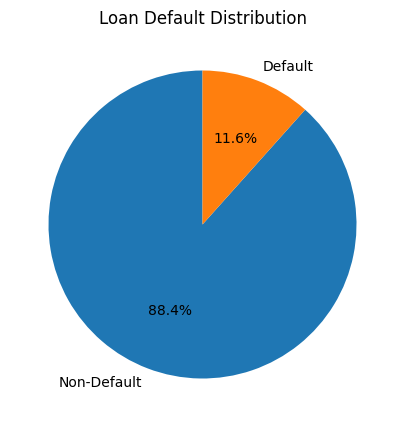

In [16]:
# Chart 1: Loan Default Distribution

default_counts = df_clean["Default"].value_counts()

plt.figure(figsize=(7, 5))

plt.pie(
    default_counts,
    labels=["Non-Default", "Default"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Loan Default Distribution")
plt.show()

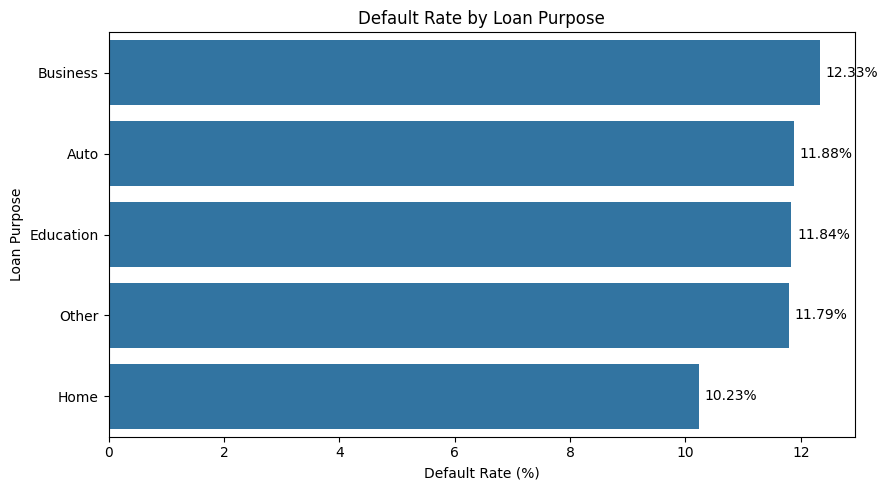

In [17]:
# Chart 2: Default Rate by Loan Purpose

purpose_chart = (
    df_clean.groupby("LoanPurpose")["Default"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=purpose_chart.values,
    y=purpose_chart.index
)

plt.xlabel("Default Rate (%)")
plt.ylabel("Loan Purpose")
plt.title("Default Rate by Loan Purpose")

for i, value in enumerate(purpose_chart.values):
    plt.text(value + 0.1, i, f"{value:.2f}%", va="center")

plt.tight_layout()
plt.show()

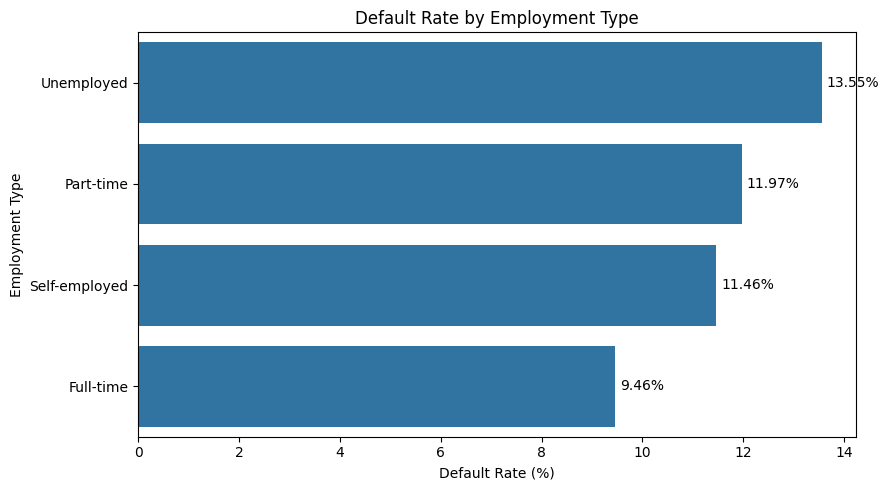

In [18]:
# Chart 3: Default Rate by Employment Type

employment_chart = (
    df_clean.groupby("EmploymentType")["Default"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=employment_chart.values,
    y=employment_chart.index
)

plt.xlabel("Default Rate (%)")
plt.ylabel("Employment Type")
plt.title("Default Rate by Employment Type")

for i, value in enumerate(employment_chart.values):
    plt.text(value + 0.1, i, f"{value:.2f}%", va="center")

plt.tight_layout()
plt.show()

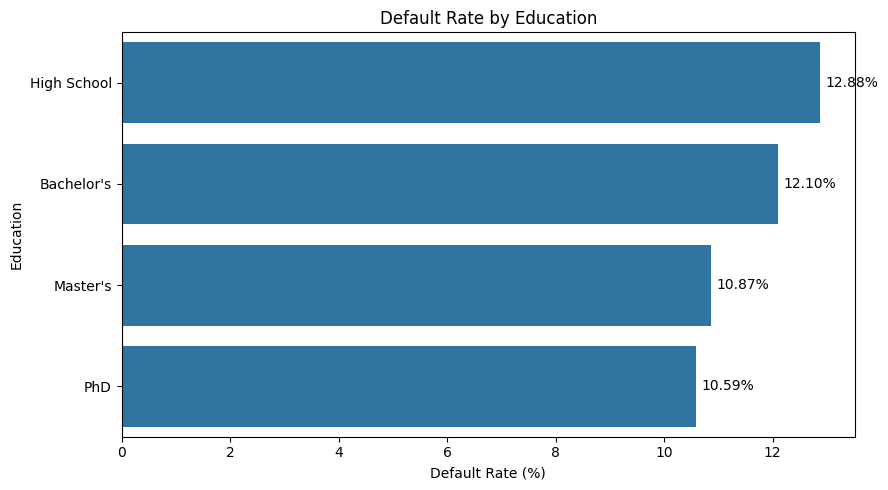

In [19]:
# Chart 4: Default Rate by Education

education_chart = (
    df_clean.groupby("Education")["Default"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=education_chart.values,
    y=education_chart.index
)

plt.xlabel("Default Rate (%)")
plt.ylabel("Education")
plt.title("Default Rate by Education")

for i, value in enumerate(education_chart.values):
    plt.text(value + 0.1, i, f"{value:.2f}%", va="center")

plt.tight_layout()
plt.show()

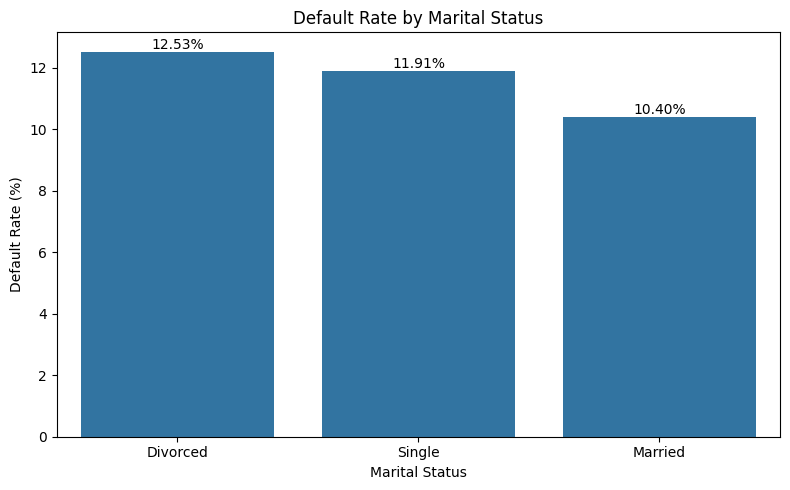

In [20]:
# Chart 5: Default Rate by Marital Status

marital_chart = (
    df_clean.groupby("MaritalStatus")["Default"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=marital_chart.index,
    y=marital_chart.values
)

plt.xlabel("Marital Status")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Marital Status")

for i, value in enumerate(marital_chart.values):
    plt.text(i, value + 0.1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

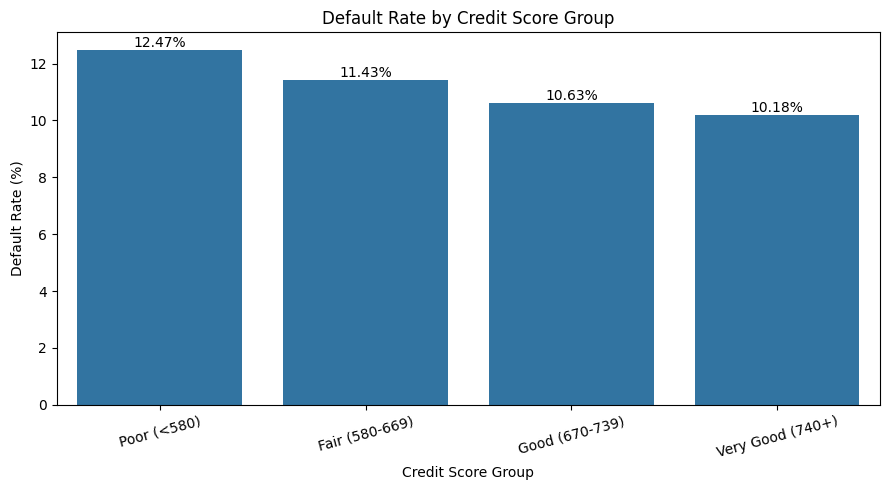

In [21]:
# Chart 6: Default Rate by Credit Score Group

credit_chart = (
    df_clean.groupby("CreditScore_Group", observed=True)["Default"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=credit_chart.index,
    y=credit_chart.values
)

plt.xlabel("Credit Score Group")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Credit Score Group")

for i, value in enumerate(credit_chart.values):
    plt.text(i, value + 0.1, f"{value:.2f}%", ha="center")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

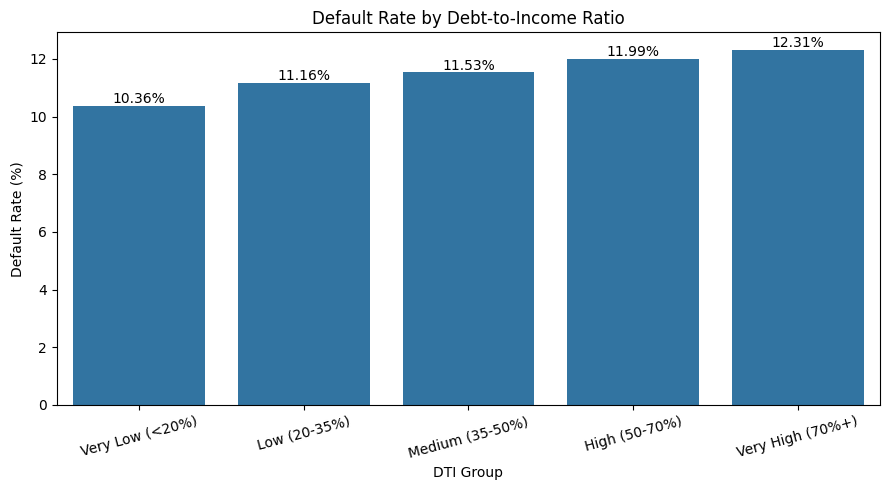

In [22]:
# Chart 7: Default Rate by DTI Group

dti_chart = (
    df_clean.groupby("DTI_Group", observed=True)["Default"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=dti_chart.index,
    y=dti_chart.values
)

plt.xlabel("DTI Group")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Debt-to-Income Ratio")

for i, value in enumerate(dti_chart.values):
    plt.text(i, value + 0.1, f"{value:.2f}%", ha="center")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

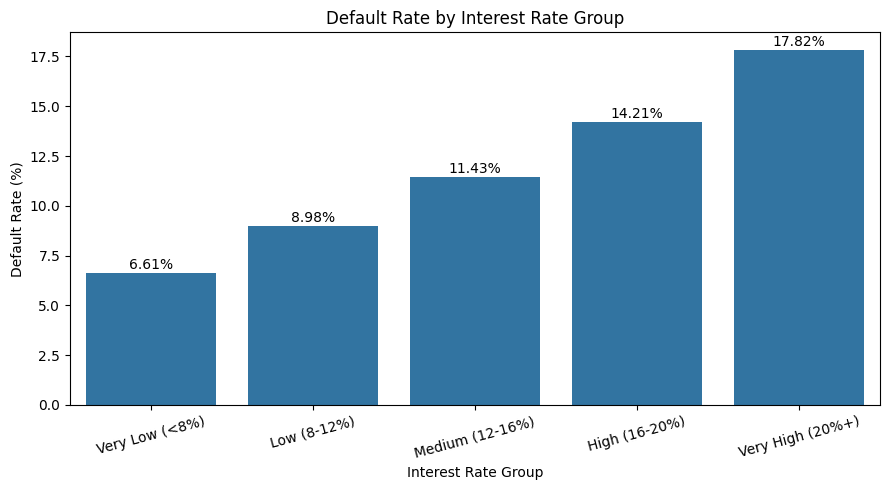

In [23]:
# Chart 8: Default Rate by Interest Rate Group

interest_chart = (
    df_clean.groupby("InterestRate_Group", observed=True)["Default"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=interest_chart.index,
    y=interest_chart.values
)

plt.xlabel("Interest Rate Group")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Interest Rate Group")

for i, value in enumerate(interest_chart.values):
    plt.text(i, value + 0.2, f"{value:.2f}%", ha="center")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

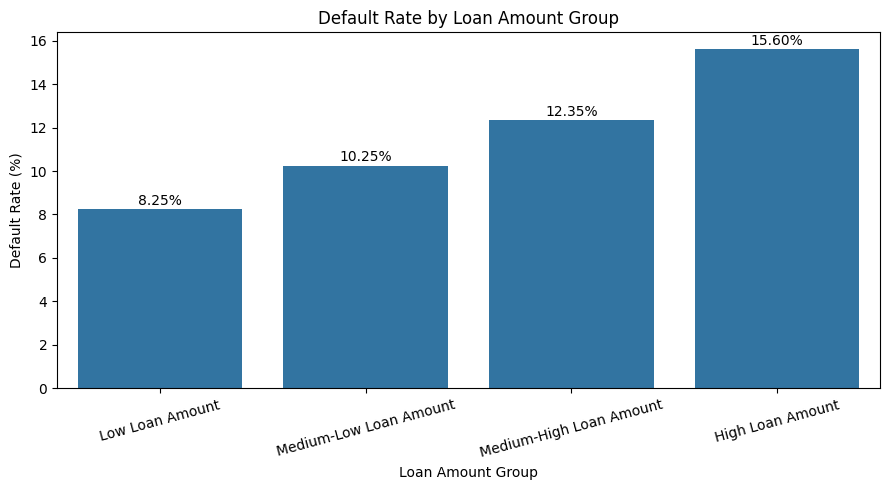

In [24]:
# Chart 9: Default Rate by Loan Amount Group

loan_amount_chart = (
    df_clean.groupby("LoanAmount_Group", observed=True)["Default"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=loan_amount_chart.index,
    y=loan_amount_chart.values
)

plt.xlabel("Loan Amount Group")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Loan Amount Group")

for i, value in enumerate(loan_amount_chart.values):
    plt.text(i, value + 0.2, f"{value:.2f}%", ha="center")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

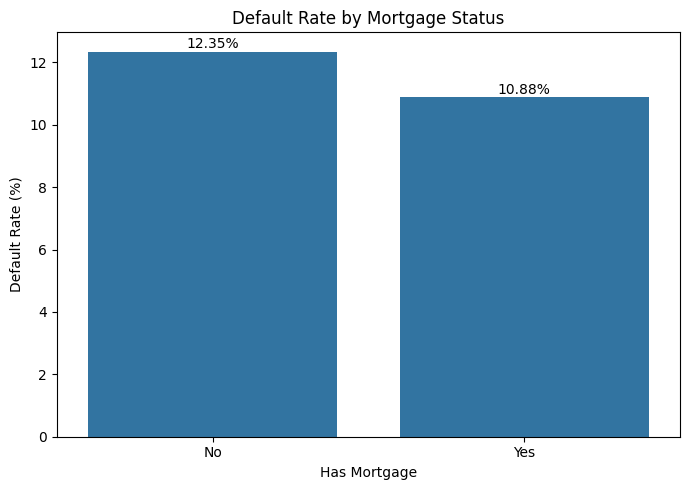

In [25]:
# Chart 10: Default Rate by Mortgage Status

mortgage_chart = (
    df_clean.groupby("HasMortgage")["Default"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=mortgage_chart.index,
    y=mortgage_chart.values
)

plt.xlabel("Has Mortgage")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Mortgage Status")

for i, value in enumerate(mortgage_chart.values):
    plt.text(i, value + 0.1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

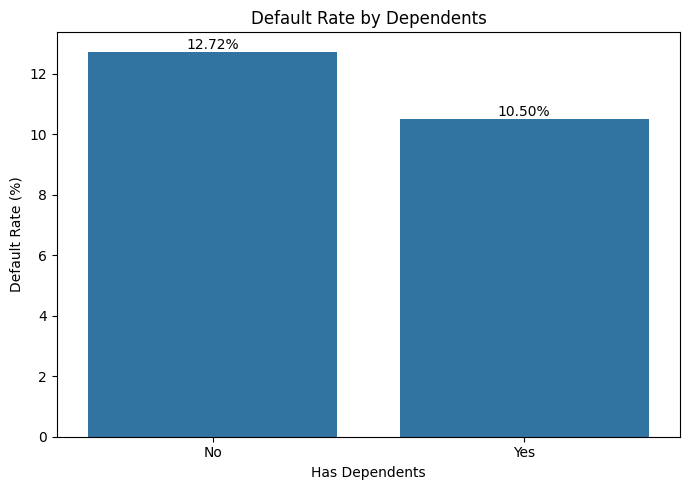

In [26]:
# Chart 11: Default Rate by Dependents

dependents_chart = (
    df_clean.groupby("HasDependents")["Default"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=dependents_chart.index,
    y=dependents_chart.values
)

plt.xlabel("Has Dependents")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Dependents")

for i, value in enumerate(dependents_chart.values):
    plt.text(i, value + 0.1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

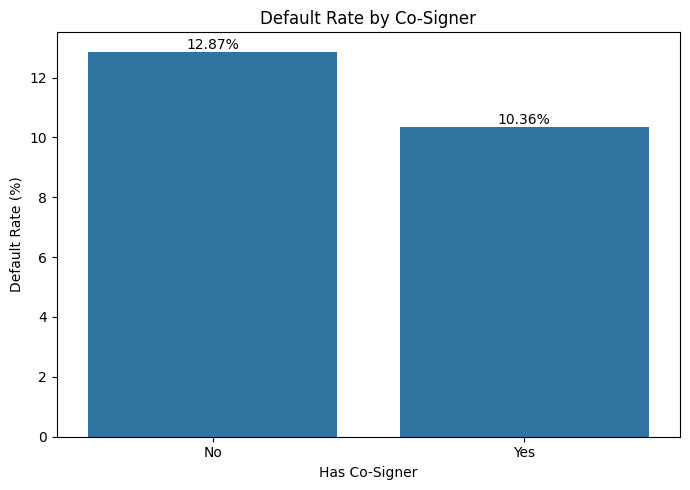

In [27]:
# Chart 12: Default Rate by Co-Signer

cosigner_chart = (
    df_clean.groupby("HasCoSigner")["Default"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=cosigner_chart.index,
    y=cosigner_chart.values
)

plt.xlabel("Has Co-Signer")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Co-Signer")

for i, value in enumerate(cosigner_chart.values):
    plt.text(i, value + 0.1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

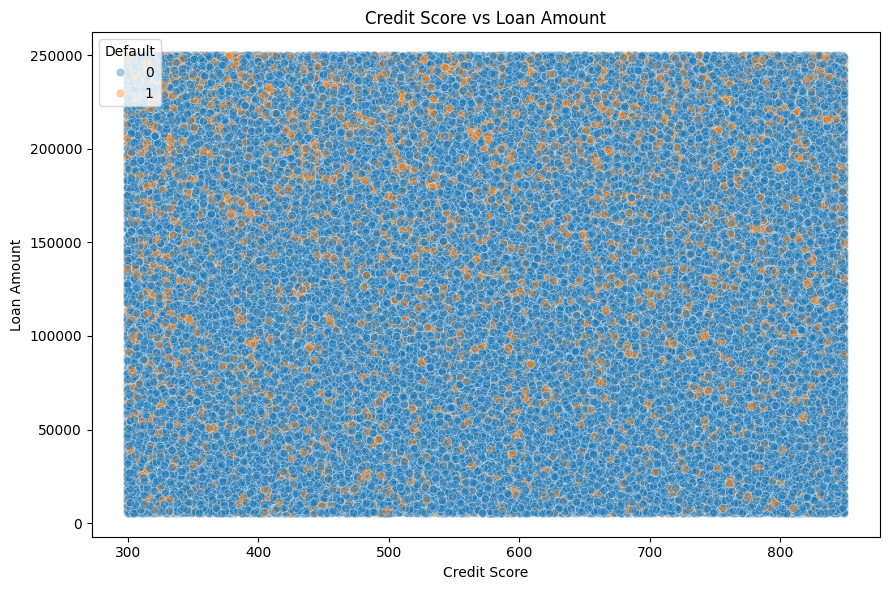

In [28]:
# Chart 13: Credit Score vs Loan Amount

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x="CreditScore",
    y="LoanAmount",
    hue="Default",
    alpha=0.4
)

plt.xlabel("Credit Score")
plt.ylabel("Loan Amount")
plt.title("Credit Score vs Loan Amount")

plt.tight_layout()
plt.show()

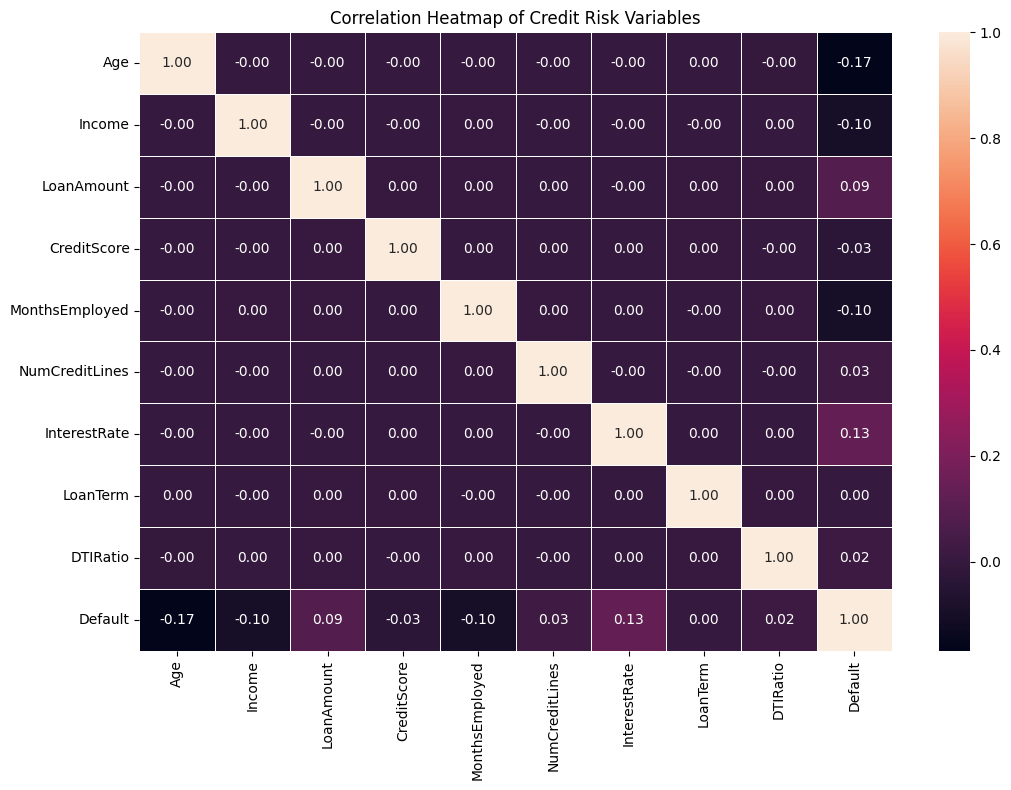

In [29]:
# Chart 14: Correlation Heatmap

numeric_columns = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "MonthsEmployed",
    "NumCreditLines",
    "InterestRate",
    "LoanTerm",
    "DTIRatio",
    "Default"
]

correlation = df_clean[numeric_columns].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Credit Risk Variables")

plt.tight_layout()
plt.show()

In [30]:
# Save final analysis dataset for Power BI

powerbi_path = "../Dataset/Loan_Credit_Risk_Cleaned.csv"

df_clean.to_csv(powerbi_path, index=False)

print("Final analysis dataset saved successfully!")
print("Shape:", df_clean.shape)
print("File:", powerbi_path)

Final analysis dataset saved successfully!
Shape: (255347, 22)
File: ../Dataset/Loan_Credit_Risk_Cleaned.csv
